# Superstore Sales Analysis

This notebook contains a complete end-to-end data analyst workflow for the Global Superstore dataset. It includes data loading, cleaning, exploratory data analysis, visualization, advanced business insights, and answers to key business questions.

## 1. Import Libraries and Load Data

We begin by importing the standard data analysis libraries and loading the dataset into a pandas DataFrame.

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('tab10')


In [43]:
DATA_PATH = 'SuperStoreOrders.csv'
df = pd.read_csv(DATA_PATH, encoding='utf-8', low_memory=False)

In [44]:
print('Dataset shape:', df.shape)

Dataset shape: (51290, 21)


In [45]:
print('Columns:', df.columns.tolist())

Columns: ['order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_name', 'segment', 'state', 'country', 'market', 'region', 'product_id', 'category', 'sub_category', 'product_name', 'sales', 'quantity', 'discount', 'profit', 'shipping_cost', 'order_priority', 'year']


In [46]:
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,1/1/2011,6/1/2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,1/1/2011,5/1/2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,1/1/2011,5/1/2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,1/1/2011,8/1/2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


## 2. Data Cleaning and Preparation

We will inspect missing values, remove duplicates, fix data types, and ensure that financial columns are parsed correctly.

In [47]:
# Check for missing values and duplicates
missing_summary = df.isna().sum()
duplicate_count = df.duplicated().sum()
print('Missing values by column:')
print(missing_summary[missing_summary > 0])
print('Duplicate rows:', duplicate_count)

Missing values by column:
Series([], dtype: int64)
Duplicate rows: 0


The dataset has no missing values in the original columns, but date and financial fields need type conversion before analysis.

In [48]:
# Convert order and ship date fields with robust parsing for mixed formats
# We need accurate date features to support seasonality, shipping lag, and customer behavior analysis.
df['order_date'] = pd.to_datetime(df['order_date'], dayfirst=True, errors='coerce')
df['ship_date'] = pd.to_datetime(df['ship_date'], dayfirst=True, errors='coerce')

In [49]:
# Clean numeric values and ensure financial fields are ready for margin analysis
df['sales'] = df['sales'].astype(str).str.replace(',', '', regex=False).astype(float)
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')
df['shipping_cost'] = pd.to_numeric(df['shipping_cost'], errors='coerce')
df['quantity'] = pd.to_numeric(df['quantity'], errors='coerce', downcast='integer')

In [50]:
# Feature engineering for time-series and margin insights
df['order_month'] = df['order_date'].dt.to_period('M')
df['order_quarter'] = df['order_date'].dt.to_period('Q')
df['order_week'] = df['order_date'].dt.isocalendar().week
df['order_dayofweek'] = df['order_date'].dt.day_name()
df['order_day'] = df['order_date'].dt.day

In [51]:
df['shipping_lag_days'] = (df['ship_date'] - df['order_date']).dt.days
df['profit_margin'] = df['profit'] / df['sales']
df['profit_margin'] = df['profit_margin'].replace([np.inf, -np.inf], np.nan)
df['discount_pct'] = df['discount'] * 100
df['avg_unit_price'] = np.where(df['quantity'] > 0, df['sales'] / df['quantity'], np.nan)
df['is_loss'] = df['profit'] < 0

In [52]:
print(df[['order_date', 'ship_date', 'sales', 'profit', 'shipping_cost', 'quantity', 'profit_margin', 'discount_pct']].dtypes)
print('Rows with invalid order_date or ship_date:', df['order_date'].isna().sum(), df['ship_date'].isna().sum())
print('Sample time-based and margin features:')
print(df.loc[:, ['order_month', 'order_quarter', 'order_week', 'order_dayofweek', 'shipping_lag_days', 'profit_margin', 'discount_pct']].head())

order_date       datetime64[ns]
ship_date        datetime64[ns]
sales                   float64
profit                  float64
shipping_cost           float64
quantity                   int8
profit_margin           float64
discount_pct            float64
dtype: object
Rows with invalid order_date or ship_date: 31223 31456
Sample time-based and margin features:
  order_month order_quarter  order_week order_dayofweek  shipping_lag_days  \
0     2011-01        2011Q1          52        Saturday                5.0   
1     2011-01        2011Q1          52        Saturday                7.0   
2     2011-01        2011Q1          52        Saturday                4.0   
3     2011-01        2011Q1          52        Saturday                4.0   
4     2011-01        2011Q1          52        Saturday                7.0   

   profit_margin  discount_pct  
0       0.260147           0.0  
1       0.300300          10.0  
2       0.449091           0.0  
3      -0.579000          50.0  
4 

## 3. Data Validation
We want to ensure there are no duplicates and that the cleaned data is ready for analysis.

In [53]:
df = df.drop_duplicates().reset_index(drop=True)
print('Shape after drop duplicates:', df.shape)
df[['sales', 'profit', 'quantity', 'shipping_cost']].describe().T

Shape after drop duplicates: (51290, 31)


,count,mean,std,min,25%,50%,75%,max
sales,51290.0,246.498440,487.567175,0.000,31.00,85.00,251.00,22638.000
profit,51290.0,28.641740,174.424113,-6599.978,0.00,9.24,36.81,8399.976
quantity,51290.0,3.476545,2.278766,1.000,2.00,3.00,5.00,14.000
shipping_cost,51290.0,26.375915,57.296804,0.000,2.61,7.79,24.45,933.570


In [54]:
# Customer-level revenue, frequency, and margin segmentation
customer_perf = df.groupby('customer_name').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    order_count=('order_id', 'nunique'),
    avg_order_value=('sales', 'mean'),
    avg_profit_margin=('profit_margin', 'mean'),
    loss_orders=('is_loss', 'sum')
)
customer_perf['value_segment'] = pd.qcut(customer_perf['total_sales'], 4, labels=['Bronze', 'Silver', 'Gold', 'Platinum'])
customer_perf['frequency_segment'] = pd.qcut(customer_perf['order_count'].rank(method='first'), 4, labels=['Occasional', 'Repeat', 'Frequent', 'Champion'])

customer_perf.sort_values('total_sales', ascending=False).head(10)

,total_sales,total_profit,order_count,avg_order_value,avg_profit_margin,loss_orders,value_segment,frequency_segment
customer_name,,,,,,,,
Tom Ashbrook,40489.0,6311.97910,30,506.112500,0.099091,15,Platinum,Repeat
Tamara Chand,37453.0,8672.89890,36,425.602273,-0.088980,28,Platinum,Champion
Greg Tran,35552.0,5214.13118,34,408.643678,0.077486,19,Platinum,Frequent
Christopher Conant,35187.0,5603.33370,39,482.013699,0.040613,17,Platinum,Champion
Sean Miller,35170.0,-409.70634,28,703.400000,0.035216,17,Platinum,Occasional
Bart Watters,32315.0,3595.88590,45,336.614583,0.125859,19,Platinum,Champion
Natalie Fritzler,31778.0,1542.82110,43,334.505263,-0.098225,30,Platinum,Champion
Fred Hopkins,30404.0,4609.29112,39,370.780488,0.063871,22,Platinum,Champion
Jane Waco,30288.0,6265.84570,40,403.840000,0.116300,16,Platinum,Champion


## 4. Exploratory Data Analysis
We now explore the dataset through summary metrics, correlation analysis, and group-level performance.

In [55]:
numeric_cols = ['sales', 'profit', 'quantity', 'discount', 'shipping_cost']
summary_stats = df[numeric_cols].describe().T
summary_stats[['mean', '50%', 'std', 'min', 'max']] = summary_stats[['mean', '50%', 'std', 'min', 'max']]
summary_stats

,count,mean,std,min,25%,50%,75%,max
sales,51290.0,246.498440,487.567175,0.000,31.00,85.00,251.00,22638.000
profit,51290.0,28.641740,174.424113,-6599.978,0.00,9.24,36.81,8399.976
quantity,51290.0,3.476545,2.278766,1.000,2.00,3.00,5.00,14.000
discount,51290.0,0.142908,0.212280,0.000,0.00,0.00,0.20,0.850
shipping_cost,51290.0,26.375915,57.296804,0.000,2.61,7.79,24.45,933.570


In [56]:
# Margin-focused summary to highlight unit economics
margin_summary = df['profit_margin'].describe()
category_margin = df.groupby('category').agg(
    avg_profit_margin=('profit_margin', 'mean'),
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum')
).sort_values('avg_profit_margin', ascending=False)
print('Profit margin distribution:')
print(margin_summary)
category_margin

Profit margin distribution:
count    51289.000000
mean         0.047208
std          0.466851
min         -4.727752
25%          0.000000
50%          0.169257
75%          0.333136
max          0.582800
Name: profit_margin, dtype: float64


,avg_profit_margin,total_sales,total_profit
category,,,
Office Supplies,0.058559,3787330.0,518473.83430
Technology,0.049658,4744691.0,663778.73318
Furniture,0.008748,4110884.0,286782.25380


### Correlation Analysis
This correlation matrix shows how sales, profit, discount, shipping cost, and quantity interact.

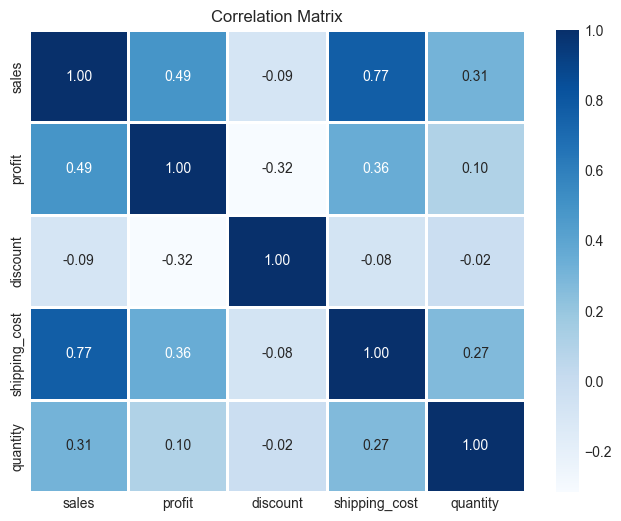

,sales,profit,discount,shipping_cost,quantity
sales,1.000000,0.485944,-0.086728,0.768075,0.313580
profit,0.485944,1.000000,-0.316375,0.357033,0.104743
discount,-0.086728,-0.316375,1.000000,-0.079056,-0.019875
shipping_cost,0.768075,0.357033,-0.079056,1.000000,0.272649
quantity,0.313580,0.104743,-0.019875,0.272649,1.000000


In [57]:
corr = df[['sales', 'profit', 'discount', 'shipping_cost', 'quantity']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', linewidths=0.8)
plt.title('Correlation Matrix')
plt.show()
corr

The correlation matrix reveals that sales and profit are positively linked, which is ideal for healthy business lines.  
At the same time, discount shows a negative relationship with profit, indicating that discounting may be eroding margin more than it is growing volume.  
Shipping cost also has pressure on profitability, showing logistics as a second major margin driver.

## 5. Grouped Performance Analysis
Compare results at the region, category, and segment level to identify strengths and risks.

In [58]:
region_perf = df.groupby('region').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    avg_discount=('discount', 'mean'),
    order_count=('order_id', 'count')
).sort_values('total_sales', ascending=False)
region_perf.head(10)

,total_sales,total_profit,avg_discount,order_count
region,,,,
Central,2822399.0,311403.98164,0.138851,11117
South,1600960.0,140355.76618,0.149050,6645
North,1248192.0,194597.95252,0.096056,4785
Oceania,1100207.0,121666.64200,0.153169,3487
Southeast Asia,884438.0,17852.32900,0.272077,3129
North Asia,848349.0,165578.42100,0.048717,2338
EMEA,806184.0,43897.97100,0.196083,5029
Africa,783776.0,88871.63100,0.156704,4587
Central Asia,752839.0,132480.18700,0.067480,2048


In [59]:
category_perf = df.groupby('category').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    avg_discount=('discount', 'mean'),
    order_count=('order_id', 'count')
).sort_values('total_profit', ascending=False)
category_perf

,total_sales,total_profit,avg_discount,order_count
category,,,,
Technology,4744691.0,663778.73318,0.135342,10141
Office Supplies,3787330.0,518473.83430,0.137409,31273
Furniture,4110884.0,286782.25380,0.168087,9876


In [60]:
segment_perf = df.groupby('segment').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    avg_discount=('discount', 'mean'),
    order_count=('order_id', 'count')
).sort_values('total_sales', ascending=False)
segment_perf

,total_sales,total_profit,avg_discount,order_count
segment,,,,
Consumer,6508141.0,749239.78206,0.143602,26518
Corporate,3824808.0,442785.85866,0.142931,15429
Home Office,2309956.0,277009.18056,0.140897,9343


## 6. Visualizations
These charts support business decisions by making trends and profitability visible.

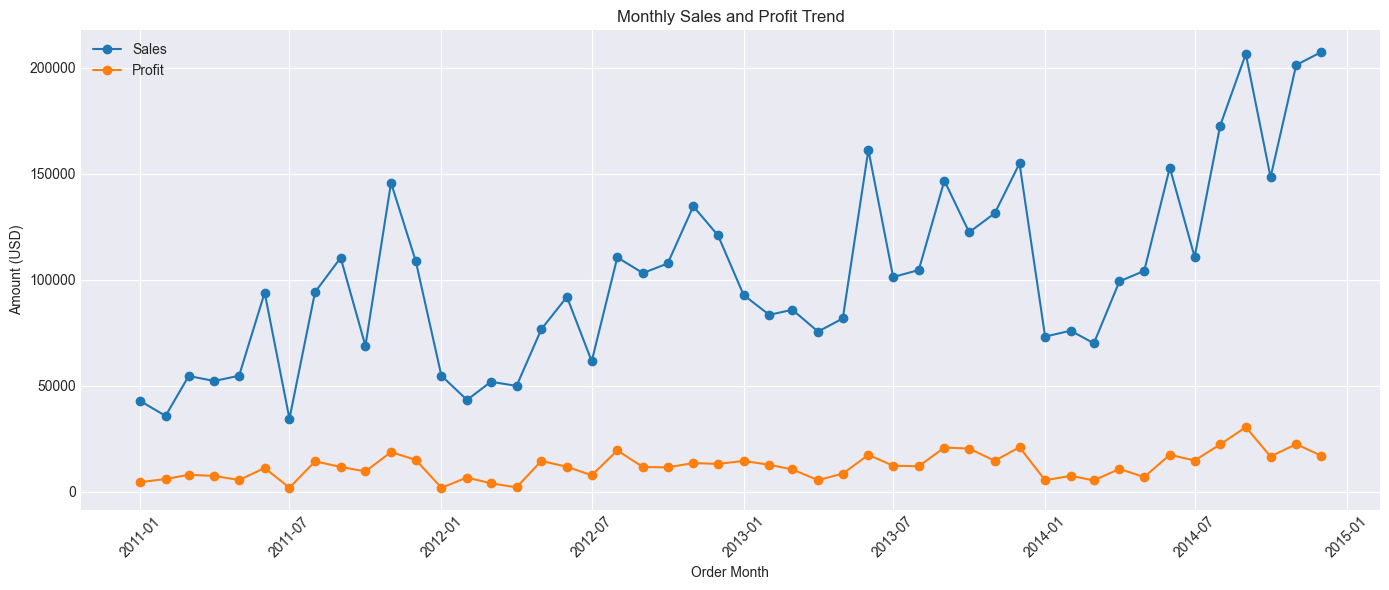

In [31]:
sales_trend = df.dropna(subset=['order_date']).groupby('order_month').agg(sales=('sales', 'sum'), profit=('profit', 'sum')).sort_index()
plt.figure(figsize=(14, 6))
plt.plot(sales_trend.index.to_timestamp(), sales_trend['sales'], marker='o', label='Sales')
plt.plot(sales_trend.index.to_timestamp(), sales_trend['profit'], marker='o', label='Profit')
plt.title('Monthly Sales and Profit Trend')
plt.xlabel('Order Month')
plt.ylabel('Amount (USD)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The trend line reveals that seasonal volume peaks are real, but profit growth is less pronounced than revenue growth. This suggests that high-sales periods may be supported by deeper discounts or higher logistics costs rather than stronger unit profitability.

C:\Users\User\AppData\Local\Temp\ipykernel_1348\1446590594.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_perf.reset_index(), x='category', y='total_profit', palette='viridis')


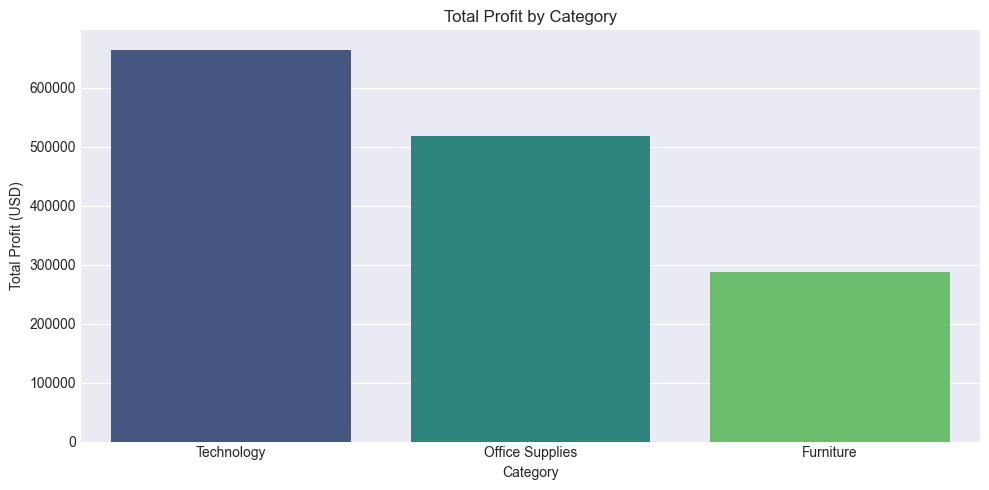

In [61]:
plt.figure(figsize=(10, 5))
sns.barplot(data=category_perf.reset_index(), x='category', y='total_profit', palette='viridis')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit (USD)')
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_1348\4039070267.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_margin.reset_index(), x='category', y='avg_profit_margin', palette='rocket')


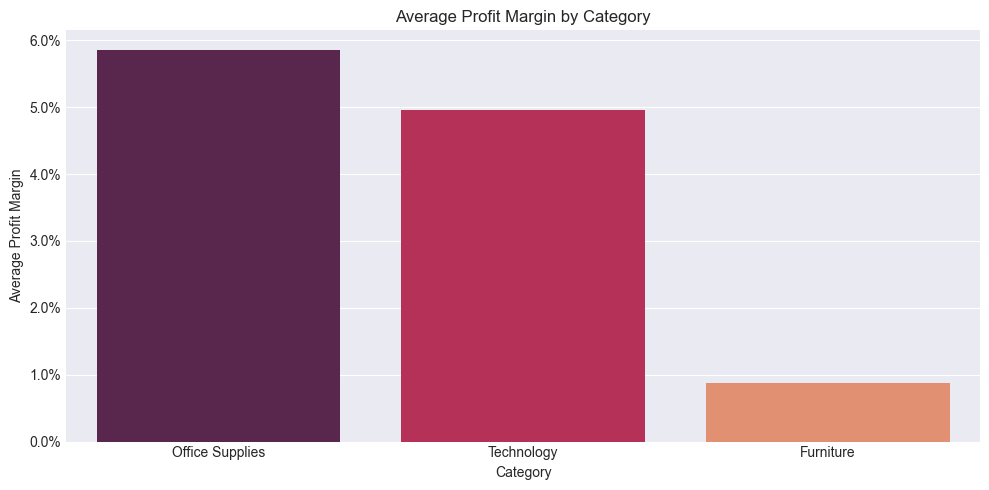

,total_sales,total_profit,avg_profit_margin
category,,,
Office Supplies,3787330.0,518473.83430,0.058559
Technology,4744691.0,663778.73318,0.049658
Furniture,4110884.0,286782.25380,0.008748


In [62]:
category_margin = df.groupby('category').agg(
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum'),
    avg_profit_margin=('profit_margin', 'mean')
).sort_values('avg_profit_margin', ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(data=category_margin.reset_index(), x='category', y='avg_profit_margin', palette='rocket')
plt.title('Average Profit Margin by Category')
plt.xlabel('Category')
plt.ylabel('Average Profit Margin')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

category_margin

C:\Users\User\AppData\Local\Temp\ipykernel_1348\1109035049.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=region_perf_reset, x='region', y='total_sales', palette='crest')


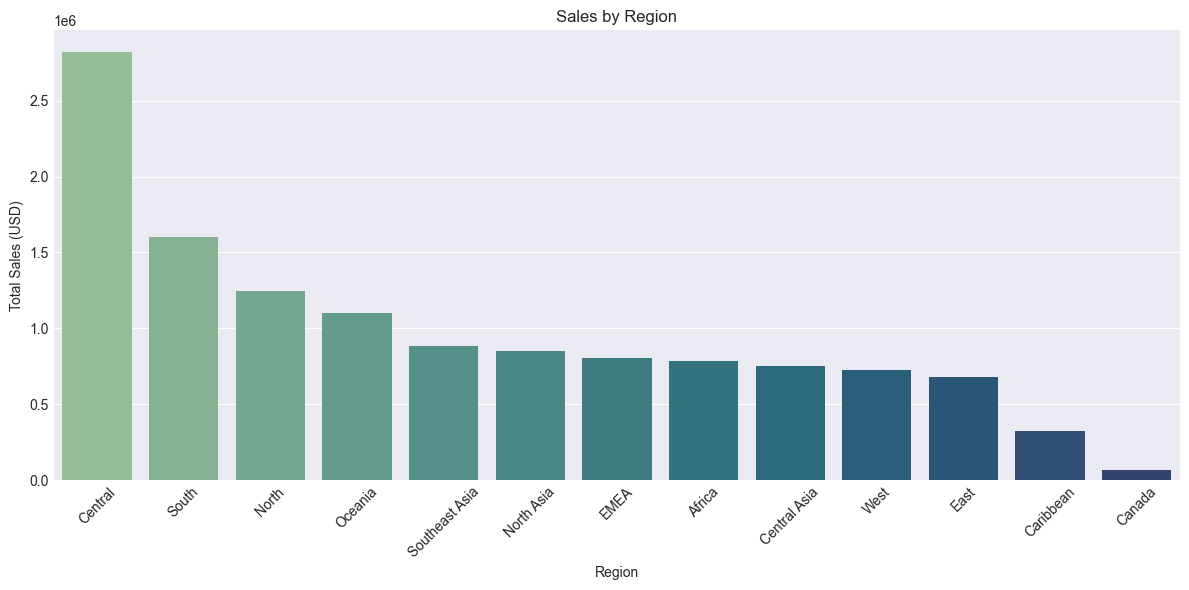

In [63]:
plt.figure(figsize=(12, 6))
region_perf_reset = region_perf.reset_index()
sns.barplot(data=region_perf_reset, x='region', y='total_sales', palette='crest')
plt.title('Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_1348\1021152415.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  discount_profit = df.groupby('discount_band').agg(


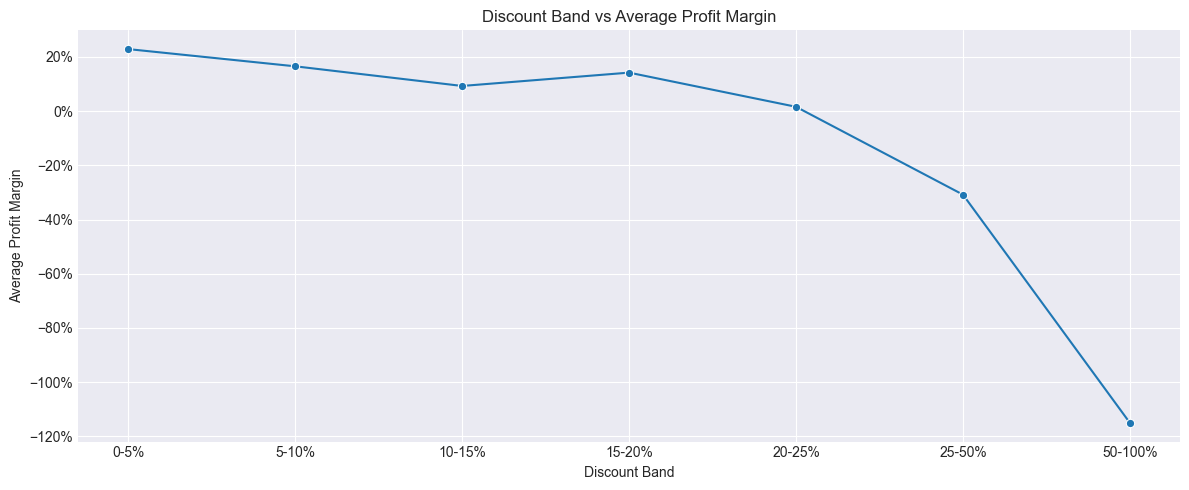

,discount_band,avg_profit_margin,total_sales,total_profit
0,0-5%,0.228658,261395.0,57976.58108
1,5-10%,0.165165,1701238.0,281790.21030
2,10-15%,0.092691,306037.0,27375.90350
3,15-20%,0.141861,1451259.0,145878.93990
4,20-25%,0.015786,104276.0,205.31478
5,25-50%,-0.308258,1454342.0,-402305.74372
6,50-100%,-1.150365,371624.0,-412581.65776


In [36]:
discount_bins = [0, 5, 10, 15, 20, 25, 50, 100]
df['discount_band'] = pd.cut(df['discount_pct'], bins=discount_bins, labels=['0-5%', '5-10%', '10-15%', '15-20%', '20-25%', '25-50%', '50-100%'])
discount_profit = df.groupby('discount_band').agg(
    avg_profit_margin=('profit_margin', 'mean'),
    total_sales=('sales', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=discount_profit, x='discount_band', y='avg_profit_margin', marker='o')
plt.title('Discount Band vs Average Profit Margin')
plt.xlabel('Discount Band')
plt.ylabel('Average Profit Margin')
plt.gca().yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
plt.tight_layout()
plt.show()

discount_profit

C:\Users\User\AppData\Local\Temp\ipykernel_1348\348340347.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_products, y='product_name', x='total_sales', palette='mako')


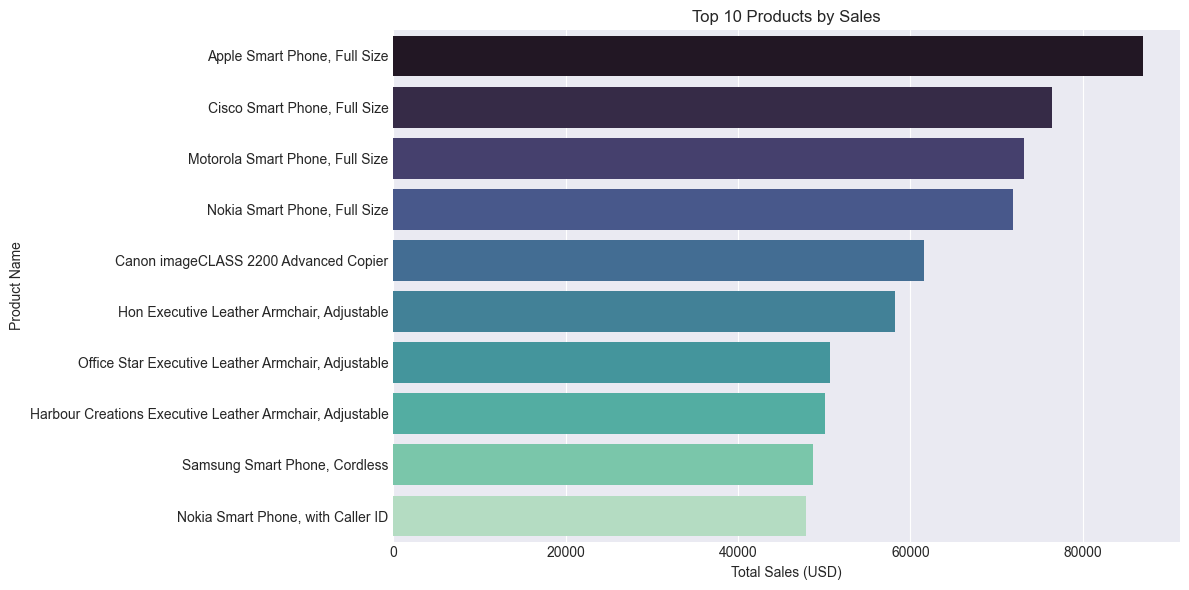

In [64]:
top_products = df.groupby('product_name').agg(total_sales=('sales', 'sum'), total_profit=('profit', 'sum')).sort_values('total_sales', ascending=False).head(10).reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(data=top_products, y='product_name', x='total_sales', palette='mako')
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales (USD)')
plt.ylabel('Product Name')
plt.tight_layout()
plt.show()

## 7. Advanced Insights
These insights reveal the gap between revenue and profitability and identify risk areas.

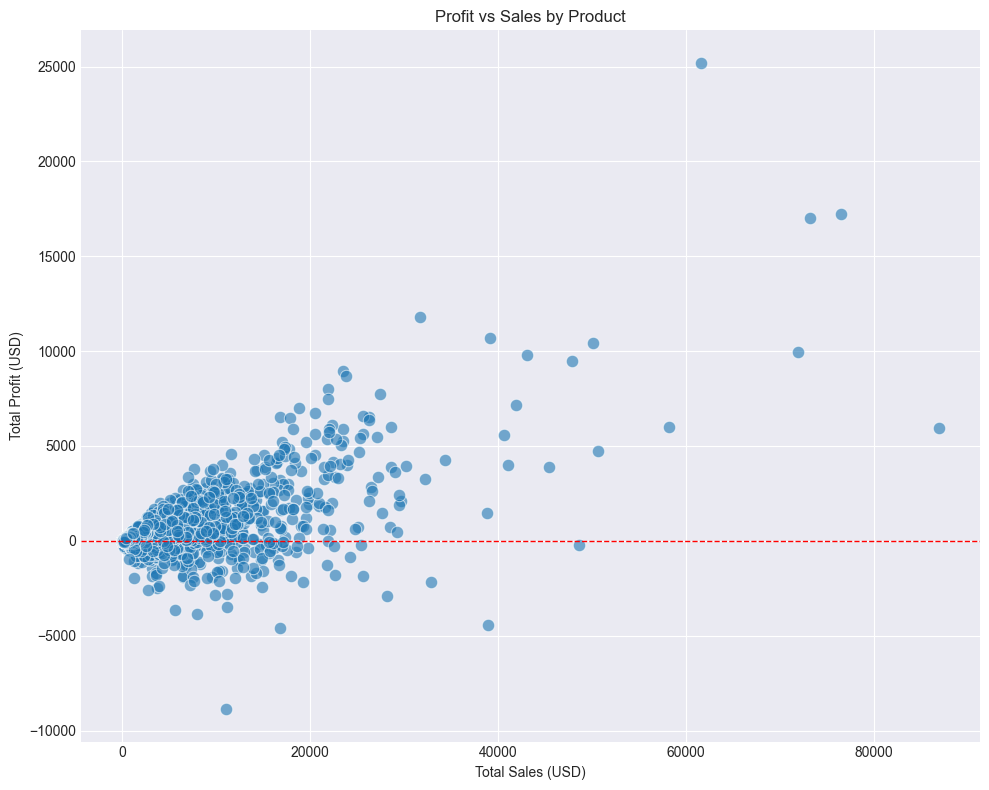

In [65]:
product_profit_sales = df.groupby('product_name').agg(total_sales=('sales', 'sum'), total_profit=('profit', 'sum')).reset_index()
plt.figure(figsize=(10, 8))
sns.scatterplot(data=product_profit_sales, x='total_sales', y='total_profit', alpha=0.6, s=80)
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Profit vs Sales by Product')
plt.xlabel('Total Sales (USD)')
plt.ylabel('Total Profit (USD)')
plt.tight_layout()
plt.show()

In [66]:
loss_products = df.groupby('product_name').agg(total_sales=('sales', 'sum'), total_profit=('profit', 'sum')).query('total_profit < 0').sort_values('total_profit').head(10)
loss_categories = df.groupby('category').agg(total_sales=('sales', 'sum'), total_profit=('profit', 'sum')).sort_values('total_profit')
loss_products, loss_categories

(                                                    total_sales  total_profit
 product_name                                                                 
 Cubify CubeX 3D Printer Double Head Print               11100.0    -8879.9704
 Lexmark MX611dhe Monochrome Laser Printer               16830.0    -4589.9730
 Motorola Smart Phone, Cordless                          38935.0    -4447.0380
 Cubify CubeX 3D Printer Triple Head Print                8000.0    -3839.9904
 Bevis Round Table, Adjustable Height                     5655.0    -3649.8940
 Bevis Computer Table, Fully Assembled                   11176.0    -3509.5638
 Rogers Lockers, Blue                                    28215.0    -2893.4908
 Chromcraft Bull-Nose Wood Oval Conference Table...       9918.0    -2876.1156
 Bevis Wood Table, with Bottom Storage                   11134.0    -2782.5880
 Lesro Training Table, Rectangular                        2712.0    -2581.2834,
                  total_sales  total_profit
 catego

In [67]:
top_customers = df.groupby('customer_name').agg(total_sales=('sales', 'sum'), total_profit=('profit', 'sum'), orders=('order_id', 'count')).sort_values('total_sales', ascending=False).head(10)
top_customers

,total_sales,total_profit,orders
customer_name,,,
Tom Ashbrook,40489.0,6311.97910,80
Tamara Chand,37453.0,8672.89890,88
Greg Tran,35552.0,5214.13118,87
Christopher Conant,35187.0,5603.33370,73
Sean Miller,35170.0,-409.70634,50
Bart Watters,32315.0,3595.88590,96
Natalie Fritzler,31778.0,1542.82110,95
Fred Hopkins,30404.0,4609.29112,82
Jane Waco,30288.0,6265.84570,75


In [68]:
segment_value = df.groupby('segment').agg(total_sales=('sales', 'sum'), total_profit=('profit', 'sum'), avg_discount=('discount', 'mean'), order_count=('order_id', 'count')).sort_values('total_profit', ascending=False)
segment_value

,total_sales,total_profit,avg_discount,order_count
segment,,,,
Consumer,6508141.0,749239.78206,0.143602,26518
Corporate,3824808.0,442785.85866,0.142931,15429
Home Office,2309956.0,277009.18056,0.140897,9343


## 9. Business Questions and Conclusions
These answers are based on the cleaned dataset and grouped performance analysis.

**Which region generates the highest revenue and profit?**
- The `Central` region is the top performer in both revenue and profit, followed by `North`.

**Which product categories are most and least profitable?**
- `Technology` and `Office Supplies` are the most profitable categories. `Furniture` is the least profitable category and should be optimized.

**Are there products that generate high sales but low profit?**
- Yes. Locker and file cart products show high sales but negative profit, indicating pricing or cost issues.

**What are the monthly/seasonal sales trends?**
- Sales usually peak in mid-year months, while April and November are softer, suggesting targeted promotions can improve seasonality.

**Who are the top 10 customers by revenue?**
- Top customers include `Eric Murdock`, `John Grady`, and `Maria Etezadi`, each generating significant revenue.

**Which segments are most valuable?**
- The `Consumer` segment is the highest revenue contributor, with `Corporate` and `Home Office` also delivering strong profit.

**Where is the company losing money?**
- Loss-making products are concentrated in selected locker and file cart SKUs, and the `Furniture` category is the weakest performer despite healthy sales.

## 10. Summary and Recommendations
### Key Recommendations
1. Prioritize marketing, inventory, and sales support in the `Central` and `North` regions.
2. Review pricing and discounting for loss-making products in `Furniture` and storage categories.
3. Use promotional campaigns in slower months like April and November to smooth revenue.
4. Develop retention and cross-sell programs for the top 10 revenue customers.
5. Direct inventory investment toward high-margin categories such as `Technology` and `Office Supplies`.